## 1. Introducción

En este ejercicio se estudia el aprendizaje continuo mediante una red neuronal convolucional (CNN) entrenada con el conjunto de datos MNIST, que contiene imágenes de dígitos escritos a mano. Para simular el aprendizaje de tareas secuenciales, los datos se dividen en dos tareas: la clasificación de los dígitos del 0 al 4 (Tarea A) y del 5 al 9 (Tarea B).

Se comparan tres estrategias: aprendizaje secuencial ingenuo (Naive), repetición de experiencias (Experience Replay) y consolidación elástica de pesos (Elastic Weight Consolidation, EWC). El objetivo es evaluar cómo cada método aprende la nueva tarea y conserva el conocimiento adquirido anteriormente, analizando el fenómeno del olvido catastrófico.


## 2. Instalación e importación de librerías

Se instalan las librerías necesarias para desarrollar el ejercicio. PyTorch y Torchvision permiten construir y entrenar la red neuronal y cargar el conjunto de datos MNIST. Matplotlib se utiliza para visualizar las imágenes y los resultados, mientras que Pandas facilita la organización y comparación de las métricas obtenidas por cada método.

In [28]:
%pip install -q torch torchvision matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 3. Importación de librerías y configuración del entorno

Se importan las librerías necesarias para manipular los datos, construir la red neuronal, entrenar los modelos y visualizar los resultados. También se establece una semilla aleatoria (`SEED = 42`) para favorecer la reproducibilidad de los experimentos.

Finalmente, se selecciona automáticamente el dispositivo de ejecución: GPU mediante CUDA, si está disponible, o CPU en caso contrario. Se imprime la versión de PyTorch y el dispositivo seleccionado para verificar la configuración del entorno.


In [29]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)

PyTorch: 2.14.1+cu130
Dispositivo: cuda


## 4. Carga del conjunto de datos MNIST

Se carga el conjunto de datos MNIST mediante Torchvision, separando las imágenes en dos subconjuntos: entrenamiento y prueba. La transformación transforms.ToTensor() convierte las imágenes en tensores que pueden ser procesados por PyTorch y escala sus valores de píxel al intervalo ([0,1]).

El parámetro download=True permite descargar automáticamente los datos si no se encuentran disponibles localmente. Finalmente, se muestra la cantidad de imágenes de cada subconjunto para verificar la carga correcta de los datos.


In [30]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Imágenes de entrenamiento:", len(train_dataset))
print("Imágenes de prueba:", len(test_dataset))

Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000


## 5. División de los datos en tareas

El conjunto MNIST se divide en dos tareas secuenciales para simular un escenario de aprendizaje continuo. La Tarea A contiene los dígitos del 0 al 4, mientras que la Tarea B contiene los dígitos del 5 al 9.

Para el entrenamiento se seleccionan 2.000 imágenes por clase, lo que representa 10.000 imágenes para cada tarea. Los conjuntos de prueba conservan todas las imágenes correspondientes a sus respectivas clases.

La función extract_tensors() selecciona las imágenes de las clases indicadas, convierte los píxeles en valores entre 0 y 1 y prepara las etiquetas como tensores. Finalmente, se imprimen las dimensiones de los datos para verificar que la división se haya realizado correctamente.


In [31]:
TASK_A = [0, 1, 2, 3, 4]
TASK_B = [5, 6, 7, 8, 9]

TRAIN_SAMPLES_PER_CLASS = 2000
BATCH_SIZE = 128

def extract_tensors(dataset, classes, max_per_class=None):
    targets = dataset.targets
    selected_indices = []

    for digit in classes:
        indices = torch.where(targets == digit)[0]

        if max_per_class is not None:
            indices = indices[:max_per_class]

        selected_indices.append(indices)

    indices = torch.cat(selected_indices)

    x = dataset.data[indices].float().unsqueeze(1) / 255.0
    y = dataset.targets[indices].long()

    return x, y


x_train_A, y_train_A = extract_tensors(
    train_dataset, TASK_A, TRAIN_SAMPLES_PER_CLASS
)

x_train_B, y_train_B = extract_tensors(
    train_dataset, TASK_B, TRAIN_SAMPLES_PER_CLASS
)

x_test_A, y_test_A = extract_tensors(test_dataset, TASK_A)
x_test_B, y_test_B = extract_tensors(test_dataset, TASK_B)

print("Tarea A:", x_train_A.shape, y_train_A.shape)
print("Tarea B:", x_train_B.shape, y_train_B.shape)
print("Prueba A:", x_test_A.shape)
print("Prueba B:", x_test_B.shape)

Tarea A: torch.Size([10000, 1, 28, 28]) torch.Size([10000])
Tarea B: torch.Size([10000, 1, 28, 28]) torch.Size([10000])
Prueba A: torch.Size([5139, 1, 28, 28])
Prueba B: torch.Size([4861, 1, 28, 28])


## 6. Visualización de ejemplos de las tareas

Se visualizan algunas imágenes de entrenamiento para comprobar cómo se distribuyen los dígitos entre las dos tareas. La primera fila muestra ejemplos de la Tarea A (dígitos del 0 al 4), mientras que la segunda presenta ejemplos de la Tarea B (dígitos del 5 al 9).

Cada imagen incluye su etiqueta correspondiente, lo que permite verificar visualmente los datos que utilizará el modelo durante el entrenamiento.


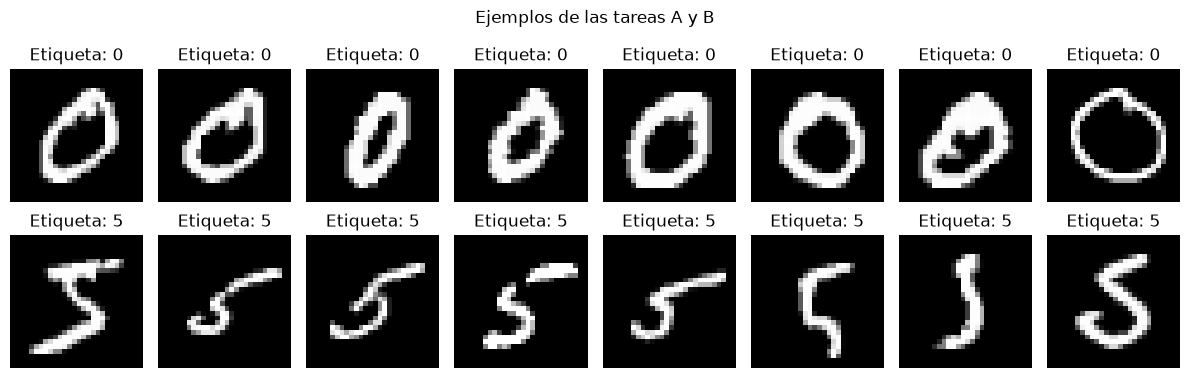

In [32]:
fig, axes = plt.subplots(2, 8, figsize=(12, 4))

for row, (images, labels) in enumerate([
    (x_train_A, y_train_A),
    (x_train_B, y_train_B)
]):
    for col in range(8):
        axes[row, col].imshow(
            images[col].squeeze(), cmap="gray"
        )
        axes[row, col].set_title(
            f"Etiqueta: {labels[col].item()}"
        )
        axes[row, col].axis("off")

plt.suptitle("Ejemplos de las tareas A y B")
plt.tight_layout()
plt.show()

## 7. Definición de la arquitectura de la red neuronal

Se define una red neuronal convolucional (CNN) denominada `DigitCNN`, diseñada para clasificar las imágenes de dígitos escritos a mano del conjunto MNIST.

La arquitectura se compone de dos bloques principales:

* **Extracción de características (`features`):** contiene dos capas convolucionales con 16 y 32 filtros, respectivamente. Cada capa utiliza la función de activación ReLU y está seguida de una operación de *Max Pooling*, que reduce las dimensiones espaciales de las imágenes y permite extraer características relevantes.
* **Clasificación (`classifier`):** convierte las características extraídas en un vector mediante `Flatten`, las procesa a través de una capa totalmente conectada de 128 neuronas y genera 10 salidas, una por cada dígito del 0 al 9.

La función `forward()` define el recorrido de los datos a través de ambos bloques. Por su parte, `create_model()` crea una instancia de la red y la asigna al dispositivo de ejecución seleccionado, ya sea CPU o GPU.

Finalmente, se guarda una copia del estado inicial de los parámetros del modelo en `INITIAL_STATE`. Este estado común permite que los tres métodos de aprendizaje continuo comiencen con los mismos parámetros iniciales, favoreciendo una comparación más consistente entre *Naive*, *Experience Replay* y *Elastic Weight Consolidation* (EWC).


In [47]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def create_model():
    return DigitCNN().to(device)


# Guardamos un estado inicial común para los tres métodos.
torch.manual_seed(SEED)
initial_model = create_model()
INITIAL_STATE = copy.deepcopy(initial_model.state_dict())

print(initial_model)

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 8. Funciones de entrenamiento y evaluación

Se implementan tres funciones auxiliares que permiten entrenar y evaluar los modelos de manera consistente durante los experimentos de aprendizaje continuo.

* **`make_loader()`:** construye un `DataLoader` a partir de las imágenes y sus etiquetas mediante `TensorDataset`. Organiza los datos en lotes del tamaño definido por `BATCH_SIZE` y permite mezclarlos durante el entrenamiento. Se utiliza una semilla fija para controlar la aleatoriedad del proceso de mezcla y favorecer la reproducibilidad de los experimentos.

* **`evaluate()`:** calcula el rendimiento del modelo sobre un conjunto de datos. Para ello, desactiva el cálculo de gradientes y utiliza el modo de evaluación mediante `model.eval()`. Retorna dos métricas: la **precisión (*accuracy*)**, expresada como porcentaje de predicciones correctas, y la **pérdida (*loss*)**, calculada mediante la entropía cruzada. Estas métricas permiten medir el desempeño del modelo en cada tarea antes y después de aprender nuevas clases.

* **`train_model()`:** realiza el entrenamiento de la red neuronal durante un número determinado de épocas, utilizando el optimizador Adam y la función de pérdida de entropía cruzada. En cada lote, calcula las predicciones, obtiene la pérdida, calcula los gradientes mediante `backward()` y actualiza los parámetros con `optimizer.step()`. También admite una función de pérdida adicional opcional (`extra_loss_fn`), que permite incorporar penalizaciones específicas de ciertos métodos, como EWC.

Al finalizar cada época, se imprime la pérdida promedio del entrenamiento y se almacena en una lista que la función retorna como historial.

Estas funciones estandarizan los procedimientos de entrenamiento y evaluación, facilitando la comparación entre los tres métodos de aprendizaje continuo.


In [48]:
def make_loader(x, y, shuffle=True):
    dataset = TensorDataset(x, y)

    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0
    )


def evaluate(model, x, y):
    model.eval()

    loader = make_loader(x, y, shuffle=False)
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return {
        "accuracy": 100.0 * correct / total,
        "loss": total_loss / total
    }


def train_model(
    model,
    x,
    y,
    epochs=3,
    lr=1e-3,
    batch_size=BATCH_SIZE,
    extra_loss_fn=None
):
    loader = make_loader(x, y, shuffle=True)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr
    )

    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            if extra_loss_fn is not None:
                loss = loss + extra_loss_fn()

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

        epoch_loss = running_loss / total
        history.append(epoch_loss)

        print(
            f"Época {epoch + 1}/{epochs} "
            f"- pérdida: {epoch_loss:.4f}"
        )

    return history

## 9. Experimento 1: Aprendizaje secuencial ingenuo (*Naive*)

En este primer experimento se implementa el método de aprendizaje secuencial ingenuo (*Naive*), que sirve como línea base para comparar las estrategias de aprendizaje continuo. El modelo comienza con los parámetros iniciales compartidos por los tres métodos y aprende las tareas de forma secuencial, sin utilizar mecanismos para conservar explícitamente el conocimiento anterior.

El procedimiento se divide en cuatro etapas:

1. **Evaluación inicial:** se mide la precisión del modelo sobre los conjuntos de prueba de las tareas A y B antes de realizar cualquier entrenamiento.
2. **Entrenamiento de la Tarea A:** el modelo aprende a clasificar los dígitos del 0 al 4 durante tres épocas. Después, se evalúa su rendimiento en ambas tareas para comprobar qué ha aprendido y cómo responde ante las clases que todavía no ha entrenado.
3. **Entrenamiento de la Tarea B:** el modelo continúa su entrenamiento con los dígitos del 5 al 9, sin volver a utilizar las imágenes de entrenamiento de la Tarea A. Al finalizar, se evalúa nuevamente en ambos conjuntos de prueba.
4. **Resumen de resultados:** se comparan las precisiones iniciales y las obtenidas después de cada fase. También se calcula el **olvido de la Tarea A**, mediante la diferencia entre su precisión después de aprender A y su precisión después de aprender B. Finalmente, se calcula la precisión promedio de ambas tareas al terminar el entrenamiento.

Este experimento permite observar el fenómeno del **olvido catastrófico**: al aprender una tarea nueva, el modelo puede modificar sus parámetros de manera que pierda parte del conocimiento adquirido anteriormente. Los resultados de este método servirán como referencia para evaluar si *Experience Replay* y EWC consiguen reducir ese efecto.


In [49]:

EPOCHS = 3
LEARNING_RATE = 1e-3

def new_model():
    model = create_model()
    model.load_state_dict(copy.deepcopy(INITIAL_STATE))
    return model


naive_model = new_model()

# 1. Estado inicial: antes de aprender ninguna tarea
naive_initial_A = evaluate(naive_model, x_test_A, y_test_A)
naive_initial_B = evaluate(naive_model, x_test_B, y_test_B)

print("=" * 45)
print("RESULTADOS INICIALES")
print("=" * 45)
print(f"Precisión A: {naive_initial_A['accuracy']:.2f}%")
print(f"Precisión B: {naive_initial_B['accuracy']:.2f}%")


# 2. Primera fase: aprender dígitos del 0 al 4
print("\n" + "=" * 45)
print("ENTRENAMIENTO DE LA TAREA A")
print("=" * 45)

train_model(
    naive_model,
    x_train_A,
    y_train_A,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

naive_after_A = {
    "A": evaluate(naive_model, x_test_A, y_test_A),
    "B": evaluate(naive_model, x_test_B, y_test_B)
}

print("\nResultados después de entrenar A:")
print(f"Precisión A: {naive_after_A['A']['accuracy']:.2f}%")
print(f"Precisión B: {naive_after_A['B']['accuracy']:.2f}%")


# 3. Segunda fase: aprender dígitos del 5 al 9 sin datos de A
print("\n" + "=" * 45)
print("ENTRENAMIENTO DE LA TAREA B")
print("=" * 45)

train_model(
    naive_model,
    x_train_B,
    y_train_B,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

naive_after_B = {
    "A": evaluate(naive_model, x_test_A, y_test_A),
    "B": evaluate(naive_model, x_test_B, y_test_B)
}

print("\nResultados después de entrenar B:")
print(f"Precisión A: {naive_after_B['A']['accuracy']:.2f}%")
print(f"Precisión B: {naive_after_B['B']['accuracy']:.2f}%")


# 4. Resumen final
olvido_A = (
    naive_after_A["A"]["accuracy"]
    - naive_after_B["A"]["accuracy"]
)

precision_promedio = (
    naive_after_B["A"]["accuracy"]
    + naive_after_B["B"]["accuracy"]
) / 2

print("\n" + "=" * 45)
print("RESUMEN FINAL: NAIVE")
print("=" * 45)

print(f"A inicial:          {naive_initial_A['accuracy']:.2f}%")
print(f"B inicial:          {naive_initial_B['accuracy']:.2f}%")
print(f"A después de A:     {naive_after_A['A']['accuracy']:.2f}%")
print(f"B después de A:     {naive_after_A['B']['accuracy']:.2f}%")
print(f"A después de B:     {naive_after_B['A']['accuracy']:.2f}%")
print(f"B después de B:     {naive_after_B['B']['accuracy']:.2f}%")
print(f"Olvido de A:        {olvido_A:.2f} puntos porcentuales")
print(f"Precisión promedio final: {precision_promedio:.2f}%")

RESULTADOS INICIALES
Precisión A: 0.74%
Precisión B: 19.46%

ENTRENAMIENTO DE LA TAREA A
Época 1/3 - pérdida: 0.6457
Época 2/3 - pérdida: 0.1383
Época 3/3 - pérdida: 0.0943

Resultados después de entrenar A:
Precisión A: 98.54%
Precisión B: 0.00%

ENTRENAMIENTO DE LA TAREA B
Época 1/3 - pérdida: 2.2045
Época 2/3 - pérdida: 0.2699
Época 3/3 - pérdida: 0.1659

Resultados después de entrenar B:
Precisión A: 0.00%
Precisión B: 95.47%

RESUMEN FINAL: NAIVE
A inicial:          0.74%
B inicial:          19.46%
A después de A:     98.54%
B después de A:     0.00%
A después de B:     0.00%
B después de B:     95.47%
Olvido de A:        98.54 puntos porcentuales
Precisión promedio final: 47.74%


## 10. Preparación de la memoria de experiencias (*Experience Replay*)

En esta sección se construye una memoria de experiencias que almacena una selección de ejemplos de la Tarea A para reutilizarlos durante el aprendizaje de la Tarea B. A diferencia del método *Naive*, esta estrategia permite que el modelo vuelva a entrenarse con una pequeña cantidad de datos de la tarea anterior, con el objetivo de reducir el olvido catastrófico.

La función `create_replay_memory()` selecciona **400 imágenes por cada clase de la Tarea A**, correspondiente a los dígitos del 0 al 4. De esta manera, la memoria contiene un total de 2.000 imágenes representativas de las clases aprendidas inicialmente.

Para realizar la selección, se identifican los índices de las imágenes de cada dígito y se aplica una permutación aleatoria controlada mediante una semilla. Esto permite obtener una selección reproducible de ejemplos. Finalmente, se almacenan copias de las imágenes y sus etiquetas en los tensores `memory_x` y `memory_y`.

Se imprimen la cantidad total de ejemplos guardados y las clases presentes en la memoria para verificar que la selección se haya realizado correctamente.

Esta memoria se utilizará posteriormente durante el entrenamiento de la Tarea B, combinando los nuevos datos de los dígitos del 5 al 9 con los ejemplos almacenados de la Tarea A. Así, el modelo podrá aprender las nuevas clases mientras repasa parte del conocimiento adquirido previamente.


In [50]:
def create_replay_memory(x, y, samples_per_class=400):
    selected = []

    for digit in TASK_A:
        indices = torch.where(y == digit)[0]

        # Selección reproducible de ejemplos de cada clase.
        generator = torch.Generator().manual_seed(SEED + digit)
        permutation = torch.randperm(
            len(indices), generator=generator
        )

        chosen = indices[permutation[:samples_per_class]]
        selected.append(chosen)

    selected = torch.cat(selected)

    return x[selected].clone(), y[selected].clone()


memory_x, memory_y = create_replay_memory(
    x_train_A,
    y_train_A,
    samples_per_class=400
)

print("Ejemplos guardados:", len(memory_y))
print("Clases en la memoria:", torch.unique(memory_y).tolist())

Ejemplos guardados: 2000
Clases en la memoria: [0, 1, 2, 3, 4]


## 11. Experimento 2: Repetición de experiencias (*Experience Replay*)

En este segundo experimento se implementa la estrategia *Experience Replay*, cuyo objetivo es reducir el olvido catastrófico mediante la reutilización de ejemplos de tareas anteriores durante el aprendizaje de nuevas clases.

El procedimiento comienza creando un modelo con los mismos parámetros iniciales utilizados en el experimento *Naive*. Posteriormente, se desarrolla el entrenamiento en dos fases:

1. **Entrenamiento de la Tarea A:** el modelo aprende a clasificar los dígitos del 0 al 4 durante el número de épocas definido. Al finalizar, se evalúa su precisión en los conjuntos de prueba de ambas tareas para establecer el rendimiento antes de incorporar la Tarea B.

2. **Entrenamiento de la Tarea B con repetición de experiencias:** se combinan las imágenes de entrenamiento de la Tarea B con los ejemplos almacenados previamente en la memoria de la Tarea A. El modelo se entrena con este conjunto combinado, lo que le permite aprender los dígitos del 5 al 9 mientras repasa ejemplos de los dígitos del 0 al 4.

Una vez finalizado el entrenamiento, se evalúa nuevamente el modelo en ambas tareas y se comparan sus precisiones antes y después de aprender B. También se calcula el **olvido de la Tarea A**, expresado en puntos porcentuales, para medir cuánto disminuye su precisión tras el aprendizaje de la nueva tarea.

A diferencia del método *Naive*, *Experience Replay* conserva una muestra de los datos anteriores y la incorpora al entrenamiento posterior. Se espera que este mecanismo ayude a mantener el rendimiento en la Tarea A sin impedir el aprendizaje de la Tarea B. Los resultados permitirán determinar qué tan efectiva es esta estrategia para mitigar el olvido catastrófico.


In [51]:

replay_model = new_model()

# Entrenamiento inicial de A
print("=" * 45)
print("ENTRENAMIENTO DE LA TAREA A")
print("=" * 45)

train_model(
    replay_model,
    x_train_A,
    y_train_A,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

replay_after_A = {
    "A": evaluate(replay_model, x_test_A, y_test_A),
    "B": evaluate(replay_model, x_test_B, y_test_B)
}

print("\nResultados después de entrenar A:")
print(f"Precisión en A: {replay_after_A['A']['accuracy']:.2f}%")
print(f"Precisión en B: {replay_after_A['B']['accuracy']:.2f}%")

# Mezclamos los datos nuevos con la memoria de A
replay_train_x = torch.cat([x_train_B, memory_x], dim=0)
replay_train_y = torch.cat([y_train_B, memory_y], dim=0)

print("\n" + "=" * 45)
print("ENTRENAMIENTO DE LA TAREA B CON EXPERIENCE REPLAY")
print("=" * 45)

train_model(
    replay_model,
    replay_train_x,
    replay_train_y,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

replay_after_B = {
    "A": evaluate(replay_model, x_test_A, y_test_A),
    "B": evaluate(replay_model, x_test_B, y_test_B)
}

print("\nResultados después de entrenar B:")
print(f"Precisión en A: {replay_after_B['A']['accuracy']:.2f}%")
print(f"Precisión en B: {replay_after_B['B']['accuracy']:.2f}%")

# Resumen final
print("\n" + "=" * 45)
print("RESUMEN FINAL DE EXPERIENCE REPLAY")
print("=" * 45)

print(f"A antes de B:  {replay_after_A['A']['accuracy']:.2f}%")
print(f"B antes de B:  {replay_after_A['B']['accuracy']:.2f}%")
print(f"A después de B: {replay_after_B['A']['accuracy']:.2f}%")
print(f"B después de B: {replay_after_B['B']['accuracy']:.2f}%")

olvido_A = (
    replay_after_A["A"]["accuracy"]
    - replay_after_B["A"]["accuracy"]
)

print(f"Olvido en A: {olvido_A:.2f} puntos porcentuales")

ENTRENAMIENTO DE LA TAREA A
Época 1/3 - pérdida: 0.6457
Época 2/3 - pérdida: 0.1383
Época 3/3 - pérdida: 0.0943

Resultados después de entrenar A:
Precisión en A: 98.54%
Precisión en B: 0.00%

ENTRENAMIENTO DE LA TAREA B CON EXPERIENCE REPLAY
Época 1/3 - pérdida: 1.8673
Época 2/3 - pérdida: 0.2988
Época 3/3 - pérdida: 0.1996

Resultados después de entrenar B:
Precisión en A: 89.86%
Precisión en B: 96.21%

RESUMEN FINAL DE EXPERIENCE REPLAY
A antes de B:  98.54%
B antes de B:  0.00%
A después de B: 89.86%
B después de B: 96.21%
Olvido en A: 8.68 puntos porcentuales


## 12. Estimación de la matriz de Fisher para EWC

Se implementa la función `estimate_fisher()`, utilizada por el método *Elastic Weight Consolidation* (EWC) para estimar la importancia de los parámetros de la red neuronal con respecto a la tarea aprendida previamente.

La función comienza colocando el modelo en modo evaluación y creando una matriz de Fisher inicializada en cero para cada parámetro entrenable. Después, selecciona aleatoriamente hasta 1.000 ejemplos del conjunto de entrenamiento de la Tarea A.

Para cada ejemplo seleccionado, se calcula la log-verosimilitud de la etiqueta correspondiente a partir de las probabilidades predichas por el modelo. Mediante `backward()`, se obtienen los gradientes de esta cantidad con respecto a los parámetros de la red. Posteriormente, se acumulan los cuadrados de dichos gradientes para estimar la importancia de cada parámetro.

Al finalizar, los valores acumulados se dividen entre el número de ejemplos procesados, obteniendo una estimación de la diagonal de la matriz de Fisher.

Esta matriz permite que EWC distinga entre parámetros con diferente importancia para la tarea anterior. Durante el entrenamiento de la Tarea B, los cambios en los parámetros asociados con valores de Fisher elevados reciben una penalización mayor, con el objetivo de preservar el conocimiento adquirido durante la Tarea A.

La función utiliza una aproximación basada en una muestra de los datos para reducir el costo computacional del cálculo.


In [52]:
def estimate_fisher(model, x, y, max_samples=1000):
    model.eval()

    fisher = {
        name: torch.zeros_like(param)
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    n = min(max_samples, len(y))
    indices = torch.randperm(len(y))[:n]

    for idx in indices:
        model.zero_grad(set_to_none=True)

        image = x[idx:idx + 1].to(device)
        label = y[idx:idx + 1].to(device)

        logits = model(image)
        log_probs = F.log_softmax(logits, dim=1)
        log_likelihood = log_probs[0, label.item()]

        log_likelihood.backward()

        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None:
                fisher[name] += param.grad.detach().pow(2)

    for name in fisher:
        fisher[name] /= n

    return fisher

## 13. Experimento 3: Consolidación elástica de pesos (*Elastic Weight Consolidation*, EWC)

En este tercer experimento se implementa *Elastic Weight Consolidation* (EWC), una estrategia de aprendizaje continuo que busca reducir el olvido catastrófico mediante una penalización que limita los cambios en los parámetros importantes para las tareas aprendidas previamente.

El procedimiento se divide en ocho etapas:

1. **Evaluación inicial:** se mide la precisión del modelo antes de entrenarlo en las tareas A y B, utilizando el mismo estado inicial que los otros métodos.
2. **Entrenamiento de la Tarea A:** el modelo aprende a clasificar los dígitos del 0 al 4. Después, se evalúa su rendimiento en ambas tareas para establecer una referencia antes de aprender B.
3. **Almacenamiento de los parámetros:** se guardan copias de los parámetros aprendidos durante la Tarea A. Estos valores servirán como referencia para calcular cuánto cambian los pesos durante el aprendizaje posterior.
4. **Estimación de la matriz de Fisher:** se estima la importancia de los parámetros del modelo a partir de hasta 1.000 ejemplos de entrenamiento de la Tarea A. Los valores de Fisher permiten asignar una mayor penalización a los cambios en los parámetros considerados más importantes para el conocimiento previo. Se imprimen estadísticas como la media, el valor máximo y la cantidad de valores positivos para inspeccionar la estimación.
5. **Definición de la penalización EWC:** se establece el hiperparámetro `EWC_LAMBDA = 15000.0`, que controla la intensidad de la penalización. Esta se calcula a partir de las diferencias entre los parámetros actuales y los guardados, ponderadas por la matriz de Fisher.
6. **Diagnóstico previo al entrenamiento de B:** se calcula la pérdida de clasificación sobre una muestra de la Tarea B y se inspecciona la penalización EWC antes de comenzar el segundo entrenamiento. También se registra el valor de lambda para facilitar el análisis del comportamiento del método.
7. **Entrenamiento de la Tarea B:** el modelo aprende los dígitos del 5 al 9 utilizando una función de pérdida compuesta por la entropía cruzada y la penalización EWC. De esta manera, el entrenamiento busca mejorar la clasificación de las nuevas clases sin modificar excesivamente los parámetros importantes para la Tarea A.
8. **Evaluación y resumen final:** se mide la precisión en ambas tareas, se calcula el olvido de A y se obtiene la precisión promedio final. Además, se ejecuta un diagnóstico para observar los cambios de los parámetros ponderados por Fisher, el cambio total de los parámetros y el valor final de la penalización.

La efectividad de EWC depende de la estimación de la importancia de los parámetros y de la intensidad de la penalización. Un valor elevado de `EWC_LAMBDA` puede restringir los cambios necesarios para aprender la nueva tarea, mientras que uno demasiado bajo puede ofrecer una protección insuficiente frente al olvido.

Los resultados de este experimento permitirán comparar EWC con *Naive* y *Experience Replay*, considerando tanto la capacidad de aprender la Tarea B como la conservación del rendimiento alcanzado previamente en la Tarea A.


In [53]:

ewc_model = new_model()

# 1. Estado inicial
ewc_initial_A = evaluate(ewc_model, x_test_A, y_test_A)
ewc_initial_B = evaluate(ewc_model, x_test_B, y_test_B)

print("=" * 45)
print("RESULTADOS INICIALES")
print("=" * 45)
print(f"Precisión A: {ewc_initial_A['accuracy']:.2f}%")
print(f"Precisión B: {ewc_initial_B['accuracy']:.2f}%")


# 2. Entrenamiento de la tarea A
print("\n" + "=" * 45)
print("ENTRENAMIENTO DE LA TAREA A")
print("=" * 45)

train_model(
    ewc_model,
    x_train_A,
    y_train_A,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

ewc_after_A = {
    "A": evaluate(ewc_model, x_test_A, y_test_A),
    "B": evaluate(ewc_model, x_test_B, y_test_B)
}

print("\nResultados después de entrenar A:")
print(f"Precisión A: {ewc_after_A['A']['accuracy']:.2f}%")
print(f"Precisión B: {ewc_after_A['B']['accuracy']:.2f}%")


# 3. Guardar parámetros aprendidos con A
old_params = {
    name: param.detach().clone()
    for name, param in ewc_model.named_parameters()
    if param.requires_grad
}


# 4. Estimar la matriz de Fisher
print("\n" + "=" * 45)
print("ESTIMACIÓN DE LA MATRIZ DE FISHER")
print("=" * 45)

fisher = estimate_fisher(
    ewc_model,
    x_train_A,
    y_train_A,
    max_samples=1000
)

fisher_values = torch.cat([
    values.detach().flatten()
    for values in fisher.values()
])

print(f"Media de Fisher: {fisher_values.mean().item():.8f}")
print(f"Máximo de Fisher: {fisher_values.max().item():.8f}")
print(f"Valores mayores que cero: {(fisher_values > 0).sum().item()}")
print(f"Total de valores: {fisher_values.numel()}")


# 5. Definir la penalización EWC
EWC_LAMBDA = 15000.0

def ewc_penalty():
    penalty = torch.zeros((), device=device)

    for name, param in ewc_model.named_parameters():
        if param.requires_grad:
            penalty += (
                fisher[name] *
                (param - old_params[name]).pow(2)
            ).sum()

    return (EWC_LAMBDA / 2) * penalty


def inspect_ewc():
    weighted_change = 0.0
    total_change = 0.0

    for name, param in ewc_model.named_parameters():
        if param.requires_grad:
            delta = param.detach() - old_params[name]

            weighted_change += (
                fisher[name] * delta.pow(2)
            ).sum().item()

            total_change += delta.pow(2).sum().item()

    print(f"Cambio ponderado por Fisher: {weighted_change:.8f}")
    print(f"Cambio total de parámetros: {total_change:.8f}")
    print(f"Penalización EWC: {ewc_penalty().item():.8f}")


# 6. Diagnóstico antes de entrenar B
ewc_model.eval()

with torch.no_grad():
    logits = ewc_model(x_train_B[:512].to(device))
    loss_B = F.cross_entropy(
        logits,
        y_train_B[:512].to(device)
    )

print("\nDiagnóstico antes de entrenar B:")
print(f"Pérdida de clasificación B: {loss_B.item():.6f}")
print(f"Penalización EWC: {ewc_penalty().item():.6f}")
print(f"Lambda: {EWC_LAMBDA}")


# 7. Entrenamiento de la tarea B con EWC
print("\n" + "=" * 45)
print("ENTRENAMIENTO DE LA TAREA B CON EWC")
print("=" * 45)

train_model(
    ewc_model,
    x_train_B,
    y_train_B,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    extra_loss_fn=ewc_penalty
)

ewc_after_B = {
    "A": evaluate(ewc_model, x_test_A, y_test_A),
    "B": evaluate(ewc_model, x_test_B, y_test_B)
}

print("\nResultados después de entrenar B:")
print(f"Precisión A: {ewc_after_B['A']['accuracy']:.2f}%")
print(f"Precisión B: {ewc_after_B['B']['accuracy']:.2f}%")


# 8. Resumen final
olvido_A = (
    ewc_after_A["A"]["accuracy"]
    - ewc_after_B["A"]["accuracy"]
)

precision_promedio = (
    ewc_after_B["A"]["accuracy"]
    + ewc_after_B["B"]["accuracy"]
) / 2

print("\n" + "=" * 45)
print("RESUMEN FINAL: EWC")
print("=" * 45)

print(f"A inicial: {ewc_initial_A['accuracy']:.2f}%")
print(f"B inicial: {ewc_initial_B['accuracy']:.2f}%")
print(f"A después de A: {ewc_after_A['A']['accuracy']:.2f}%")
print(f"B después de A: {ewc_after_A['B']['accuracy']:.2f}%")
print(f"A después de B: {ewc_after_B['A']['accuracy']:.2f}%")
print(f"B después de B: {ewc_after_B['B']['accuracy']:.2f}%")
print(f"Olvido de A: {olvido_A:.2f} puntos porcentuales")
print(f"Precisión promedio final: {precision_promedio:.2f}%")

print("\nDiagnóstico final de EWC:")
inspect_ewc()

RESULTADOS INICIALES
Precisión A: 0.74%
Precisión B: 19.46%

ENTRENAMIENTO DE LA TAREA A
Época 1/3 - pérdida: 0.6457
Época 2/3 - pérdida: 0.1383
Época 3/3 - pérdida: 0.0943

Resultados después de entrenar A:
Precisión A: 98.54%
Precisión B: 0.00%

ESTIMACIÓN DE LA MATRIZ DE FISHER
Media de Fisher: 0.00046155
Máximo de Fisher: 2.14765072
Valores mayores que cero: 89706
Total de valores: 206922

Diagnóstico antes de entrenar B:
Pérdida de clasificación B: 21.114563
Penalización EWC: 0.000000
Lambda: 15000.0

ENTRENAMIENTO DE LA TAREA B CON EWC
Época 1/3 - pérdida: 4.6313
Época 2/3 - pérdida: 1.0214
Época 3/3 - pérdida: 0.6279

Resultados después de entrenar B:
Precisión A: 17.10%
Precisión B: 88.07%

RESUMEN FINAL: EWC
A inicial: 0.74%
B inicial: 19.46%
A después de A: 98.54%
B después de A: 0.00%
A después de B: 17.10%
B después de B: 88.07%
Olvido de A: 81.44 puntos porcentuales
Precisión promedio final: 52.59%

Diagnóstico final de EWC:
Cambio ponderado por Fisher: 0.00001510
Cambio t

## 14. Comparación de resultados

En esta sección se consolidan las métricas obtenidas por los tres métodos de aprendizaje continuo: *Naive*, *Experience Replay* y *Elastic Weight Consolidation* (EWC). Para ello, se utiliza un DataFrame de Pandas que organiza los resultados en una tabla comparativa.

Se analizan las siguientes métricas:

* **A antes de B:** precisión obtenida en la Tarea A después de entrenar el modelo con los dígitos del 0 al 4, antes de comenzar el entrenamiento de la Tarea B.
* **B antes de B:** precisión sobre la Tarea B antes de entrenarla. Esta métrica permite observar el rendimiento inicial del modelo frente a las clases que aún no ha aprendido.
* **A después de B:** precisión en la Tarea A una vez finalizado el entrenamiento de la Tarea B. Su comparación con la precisión anterior permite evaluar la conservación del conocimiento previo.
* **B después de B:** precisión alcanzada en la Tarea B después de completar su entrenamiento.
* **Olvido de A (puntos porcentuales):** diferencia entre la precisión de A antes y después de aprender B. Un valor positivo elevado indica una mayor pérdida de rendimiento en la tarea anterior; un valor cercano a cero indica que se conservó mejor su desempeño.
* **Cambio de B (puntos porcentuales):** diferencia entre la precisión de B después y antes de su entrenamiento. Permite observar cuánto mejoró el modelo en la nueva tarea.
* **Precisión promedio final:** promedio de las precisiones obtenidas en A y B al terminar el entrenamiento. Proporciona una medida general del rendimiento del modelo en ambas tareas.

Finalmente, los resultados se redondean a dos decimales para facilitar su lectura y comparación.

Esta tabla constituye la base para determinar qué estrategia ofrece el mejor equilibrio entre el aprendizaje de nuevas clases y la conservación del conocimiento previo. En particular, permite comprobar si *Experience Replay* y EWC reducen el olvido observado en el método *Naive* y si esa reducción se acompaña de un buen rendimiento en la Tarea B.


In [54]:
results = {
    "Naive": {
        "A_antes_B": naive_after_A["A"]["accuracy"],
        "B_antes_B": naive_after_A["B"]["accuracy"],
        "A_despues_B": naive_after_B["A"]["accuracy"],
        "B_despues_B": naive_after_B["B"]["accuracy"],
    },
    "Experience Replay": {
        "A_antes_B": replay_after_A["A"]["accuracy"],
        "B_antes_B": replay_after_A["B"]["accuracy"],
        "A_despues_B": replay_after_B["A"]["accuracy"],
        "B_despues_B": replay_after_B["B"]["accuracy"],
    },
    "EWC": {
        "A_antes_B": ewc_after_A["A"]["accuracy"],
        "B_antes_B": ewc_after_A["B"]["accuracy"],
        "A_despues_B": ewc_after_B["A"]["accuracy"],
        "B_despues_B": ewc_after_B["B"]["accuracy"],
    },
}

df = pd.DataFrame(results).T

df["Olvido_A_pp"] = (
    df["A_antes_B"] - df["A_despues_B"]
)

df["Cambio_B_pp"] = (
    df["B_despues_B"] - df["B_antes_B"]
)

df["Precision_promedio_final"] = (
    df["A_despues_B"] + df["B_despues_B"]
) / 2

df = df.round(2)

print("Resultados de aprendizaje continuo:")
display(df)

Resultados de aprendizaje continuo:


,A_antes_B,B_antes_B,A_despues_B,B_despues_B,Olvido_A_pp,Cambio_B_pp,Precision_promedio_final
Naive,98.54,0.0,0.00,95.47,98.54,95.47,47.74
Experience Replay,98.54,0.0,89.86,96.21,8.68,96.21,93.04
EWC,98.54,0.0,17.10,88.07,81.44,88.07,52.59


## 15. Visualización de la precisión por tarea

Se construye un gráfico de barras agrupadas para comparar el rendimiento de los tres métodos de aprendizaje continuo (*Naive*, *Experience Replay* y EWC) en las tareas A y B, antes y después del entrenamiento de la Tarea B.

Para cada método se representan cuatro métricas: la precisión en A antes de aprender B, la precisión en A después de aprender B, la precisión en B antes de su entrenamiento y la precisión en B después de su entrenamiento.

El eje horizontal identifica los métodos evaluados, mientras que el eje vertical representa la precisión en porcentaje. La leyenda permite distinguir cada etapa del aprendizaje y la cuadrícula facilita la comparación visual de los valores.

Este gráfico permite identificar dos aspectos principales: **la capacidad de conservar el conocimiento de la Tarea A** y **la capacidad de aprender la Tarea B**. Una disminución considerable de la precisión en A después de entrenar B puede indicar olvido catastrófico, mientras que una precisión elevada en ambas tareas al finalizar el entrenamiento refleja un mejor equilibrio entre la retención del conocimiento y el aprendizaje de nuevas clases.

La visualización complementa la tabla de resultados y facilita la identificación de diferencias entre las estrategias evaluadas.


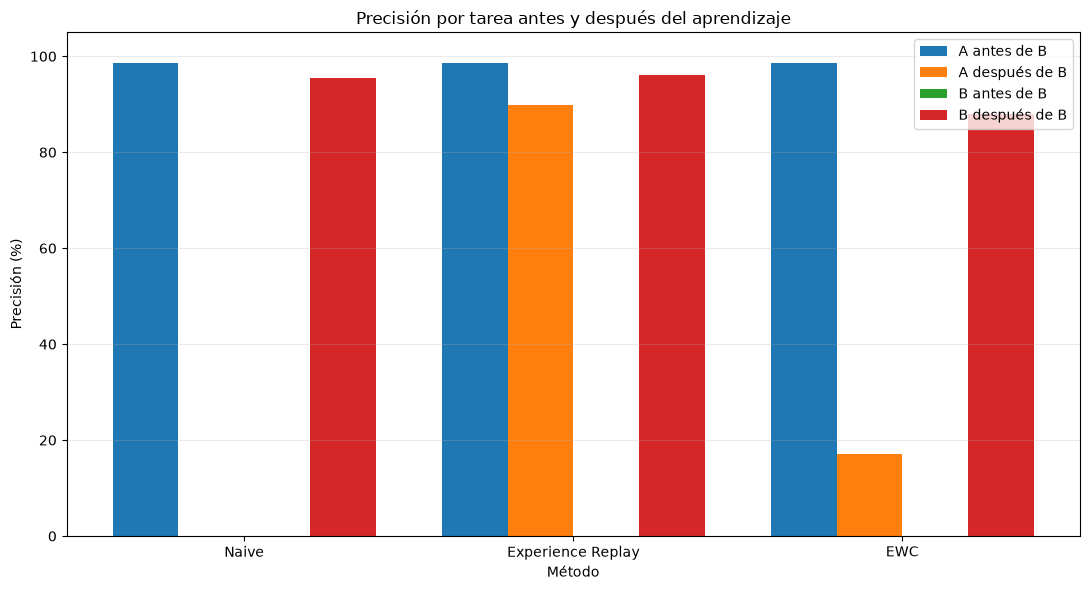

In [55]:
methods = df.index.tolist()
x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x - 1.5 * width,
    df["A_antes_B"],
    width,
    label="A antes de B"
)

ax.bar(
    x - 0.5 * width,
    df["A_despues_B"],
    width,
    label="A después de B"
)

ax.bar(
    x + 0.5 * width,
    df["B_antes_B"],
    width,
    label="B antes de B"
)

ax.bar(
    x + 1.5 * width,
    df["B_despues_B"],
    width,
    label="B después de B"
)

ax.set_ylabel("Precisión (%)")
ax.set_xlabel("Método")
ax.set_title("Precisión por tarea antes y después del aprendizaje")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 16. Comparación del olvido catastrófico

Se genera un gráfico de barras que compara el olvido de la Tarea A entre los tres métodos evaluados: *Naive*, *Experience Replay* y *Elastic Weight Consolidation* (EWC).

El olvido se calcula como la diferencia, en puntos porcentuales, entre la precisión obtenida en la Tarea A después de entrenar con A y la precisión obtenida después de entrenar con B. Cada barra representa el valor calculado para uno de los métodos, y las etiquetas numéricas permiten consultar los resultados exactos.

La línea horizontal en cero sirve como referencia para interpretar las diferencias:

* **Olvido positivo:** la precisión en A disminuyó después de aprender B.
* **Olvido cercano a cero:** el modelo conservó aproximadamente su rendimiento en A.
* **Olvido negativo:** la precisión en A aumentó después de aprender B.

El objetivo de esta visualización es identificar qué estrategia conserva mejor el conocimiento adquirido durante la primera tarea. En particular, permite comprobar si los mecanismos de repetición de experiencias y penalización de parámetros reducen el olvido en comparación con el aprendizaje secuencial ingenuo.

Un menor valor de olvido indica una mejor conservación del rendimiento en A, aunque debe analizarse junto con la precisión final de B para determinar si el método también aprendió correctamente la nueva tarea.


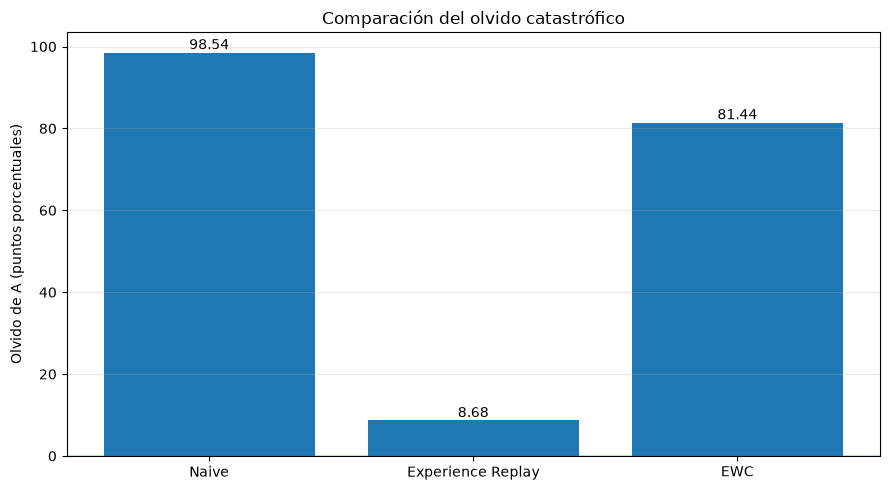

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df.index,
    df["Olvido_A_pp"]
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Olvido de A (puntos porcentuales)")
ax.set_title("Comparación del olvido catastrófico")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, df["Olvido_A_pp"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

## 17. Comparación de la precisión promedio final

Se construye un gráfico de barras para comparar la precisión promedio final alcanzada por los tres métodos de aprendizaje continuo: *Naive*, *Experience Replay* y *Elastic Weight Consolidation* (EWC).

La métrica se calcula como el promedio de las precisiones obtenidas en las tareas A y B después de completar ambos entrenamientos. De esta manera, se evalúa el rendimiento global de cada modelo, considerando tanto su capacidad para conservar el conocimiento anterior como su capacidad para aprender las nuevas clases.

El eje horizontal representa los métodos evaluados y el eje vertical muestra la precisión promedio en porcentaje. El límite superior del eje vertical se establece en 105 % para facilitar la visualización de los resultados.

Este gráfico permite identificar qué estrategia consigue el mejor equilibrio entre ambas tareas. Sin embargo, la precisión promedio debe interpretarse junto con el gráfico de olvido catastrófico, ya que dos métodos pueden obtener promedios similares y presentar diferencias importantes en la conservación del conocimiento de la Tarea A.


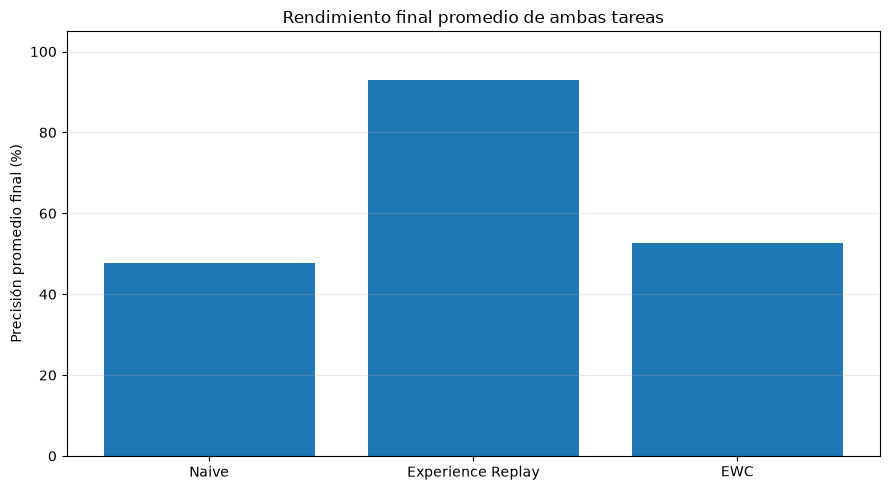

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    df.index,
    df["Precision_promedio_final"]
)

ax.set_ylabel("Precisión promedio final (%)")
ax.set_title("Rendimiento final promedio de ambas tareas")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 18. Evolución del rendimiento durante el aprendizaje

En esta sección se construye una tabla que permite observar la evolución de la precisión de los tres métodos a lo largo de las diferentes etapas del experimento. A diferencia de la comparación anterior, que se centra en las métricas finales, esta tabla incluye también el estado inicial de los modelos y los resultados obtenidos después de cada fase de entrenamiento.

Se registran las siguientes métricas para cada método:

* **A inicial y B inicial:** precisión del modelo antes de aprender cualquiera de las dos tareas. Se utilizan los mismos valores iniciales para los tres métodos, dado que todos parten de los mismos parámetros.
* **A después de A:** precisión en la Tarea A una vez finalizado su entrenamiento inicial.
* **B después de A:** precisión en la Tarea B después de entrenar únicamente con los dígitos del 0 al 4.
* **A después de B:** precisión en la Tarea A después de completar el entrenamiento secuencial de ambas tareas.
* **B después de B:** precisión final en la Tarea B después de su entrenamiento.

Los resultados se organizan en un DataFrame de Pandas, utilizando el nombre de cada método como índice y redondeando las precisiones a dos decimales.

Esta tabla permite analizar el proceso de aprendizaje de forma cronológica: cómo mejora el rendimiento en la primera tarea, cómo responde el modelo ante clases que todavía no ha aprendido y qué sucede con el conocimiento anterior al incorporar la segunda tarea.

De esta manera, se complementan las comparaciones de olvido catastrófico y precisión promedio final, proporcionando una visión más completa del comportamiento de *Naive*, *Experience Replay* y EWC.


In [58]:
initial_A = naive_initial_A["accuracy"]
initial_B = naive_initial_B["accuracy"]

evolution = pd.DataFrame([
    {
        "Método": "Naive",
        "A_inicial": initial_A,
        "B_inicial": initial_B,
        "A_despues_A": naive_after_A["A"]["accuracy"],
        "B_despues_A": naive_after_A["B"]["accuracy"],
        "A_despues_B": naive_after_B["A"]["accuracy"],
        "B_despues_B": naive_after_B["B"]["accuracy"],
    },
    {
        "Método": "Experience Replay",
        "A_inicial": initial_A,
        "B_inicial": initial_B,
        "A_despues_A": replay_after_A["A"]["accuracy"],
        "B_despues_A": replay_after_A["B"]["accuracy"],
        "A_despues_B": replay_after_B["A"]["accuracy"],
        "B_despues_B": replay_after_B["B"]["accuracy"],
    },
    {
        "Método": "EWC",
        "A_inicial": initial_A,
        "B_inicial": initial_B,
        "A_despues_A": ewc_after_A["A"]["accuracy"],
        "B_despues_A": ewc_after_A["B"]["accuracy"],
        "A_despues_B": ewc_after_B["A"]["accuracy"],
        "B_despues_B": ewc_after_B["B"]["accuracy"],
    }
])

evolution = evolution.set_index("Método").round(2)
display(evolution)

,A_inicial,B_inicial,A_despues_A,B_despues_A,A_despues_B,B_despues_B
Método,,,,,,
Naive,0.74,19.46,98.54,0.0,0.00,95.47
Experience Replay,0.74,19.46,98.54,0.0,89.86,96.21
EWC,0.74,19.46,98.54,0.0,17.10,88.07


## 19. Visualización de ejemplos de todas las clases de MNIST

En esta sección se combinan los conjuntos de entrenamiento de las tareas A y B para obtener un conjunto que contiene ejemplos de los diez dígitos de MNIST, del 0 al 9.

A continuación, se genera una cuadrícula de 10 filas y 10 columnas, en la que cada fila corresponde a un dígito y contiene diez imágenes seleccionadas aleatoriamente, sin repetir índices dentro de la misma fila.

Para cada imagen, se convierten los datos del tensor en una matriz que puede visualizarse mediante Matplotlib. Las imágenes se muestran en escala de grises y se ocultan los ejes para facilitar su inspección. Además, se etiqueta cada fila con el dígito correspondiente.

Esta visualización permite observar la variabilidad de la escritura a mano en las diez clases y comprobar que los datos utilizados en ambas tareas representan correctamente los dígitos de MNIST.

La selección aleatoria permite observar distintos ejemplos en cada ejecución. Si se desea obtener la misma selección en ejecuciones posteriores, es necesario establecer una semilla aleatoria antes de generar los índices.


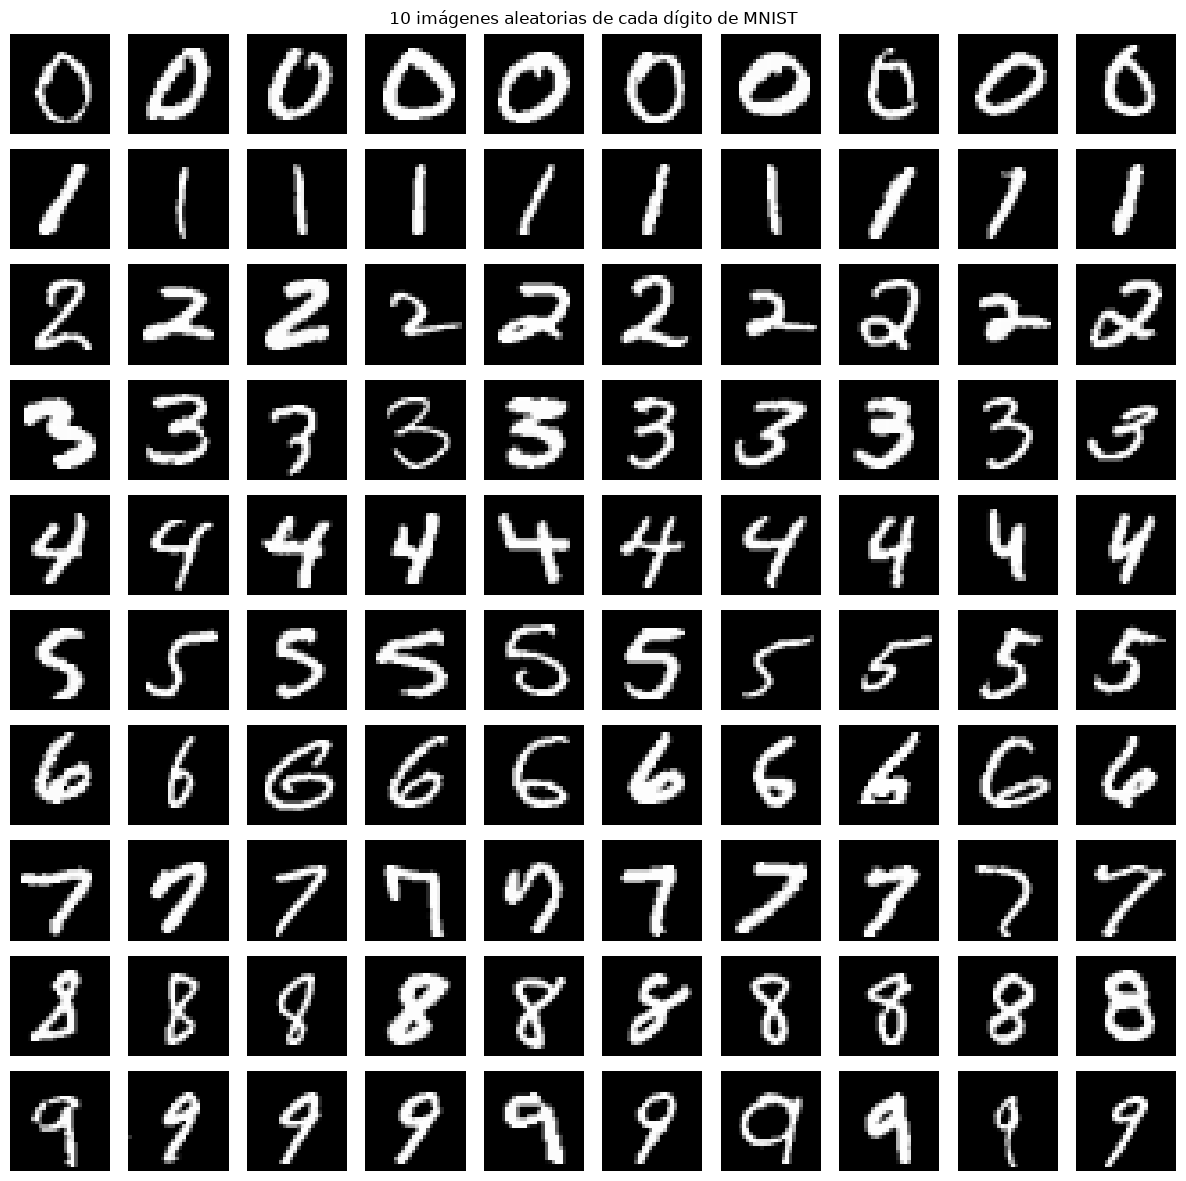

In [59]:
x_train = torch.cat([x_train_A, x_train_B], dim=0)
y_train = torch.cat([y_train_A, y_train_B], dim=0)

import matplotlib.pyplot as plt
import torch

fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digito in range(10):
    # Encontrar todas las imágenes correspondientes al dígito
    indices = torch.where(y_train == digito)[0]

    # Seleccionar 10 índices aleatorios sin repetir
    indices_aleatorios = indices[
        torch.randperm(len(indices))[:10]
    ]

    for columna, idx in enumerate(indices_aleatorios):
        imagen = x_train[idx].squeeze().cpu().numpy()

        axes[digito, columna].imshow(imagen, cmap="gray")
        axes[digito, columna].axis("off")

        if columna == 0:
            axes[digito, columna].set_ylabel(
                f"Dígito {digito}", fontsize=10
            )

plt.suptitle("10 imágenes aleatorias de cada dígito de MNIST")
plt.tight_layout()
plt.show()